# Notebook 4 — Does the noise covariance *source* (data vs LOO) matter?

The reference DP mechanism protects a released statistic by adding **correlated** noise. The noise's
*correlation structure* can be estimated two ways:

- **from the data** — `Cov(subject data)` (what the reference does), or
- **from the LOO perturbations** — `Cov(d_i)`, where `d_i = stat(D \ x_i) − stat(D)` is how each subject
  actually moves the released statistic.

The noise *magnitude* is set identically in both cases (marginal SD = `2·loo_scale`), so **the only thing that
differs between the two mechanisms is the correlation of the noise.** This notebook asks one question, at two
levels:

> **Does the covariance source change anything — and for which statistics?**

1. **Structural (Experiment A).** Before any noise is drawn: how far apart are the two covariance sources, per
   statistic? We expect them to *coincide exactly* for the linear **mean** (a provable anchor) and to diverge
   as the statistic becomes more non-linear (trimmed mean → median).
2. **Outcome (Experiment B).** After noise is drawn and a membership attacker is run: does that structural
   divergence actually change measured **privacy**? We use the shared `privacy_harness.py` with seed-based 95%
   CIs, so a difference only counts if the intervals separate.

A short **caveat** covers a distinct failure mode — the median's *degeneracy* on coarsely-recorded data (a
zero-noise blind spot).

*Substrate.* We use a **controlled bivariate population** (a weight/height-like Gaussian with a set
correlation) so the covariance-source effect is isolated from data-recording artifacts. Any real table can be
dropped in via `ph.TabularSource`; a flag below shows how.

Requires `privacy_harness.py` and `cov_diagnostics.py` next to this notebook.

In [2]:
import sys, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import trim_mean

# make the harness importable (next to the notebook, or in ./harness)
for cand in [".", "harness", os.path.expanduser("~/harness")]:
    if os.path.exists(os.path.join(cand, "privacy_harness.py")):
        sys.path.insert(0, cand); break
import privacy_harness as ph
import cov_diagnostics as cd
print("harness + diagnostics loaded")

harness + diagnostics loaded


## Data and the statistic ladder

The substrate is a controlled bivariate Gaussian with a chosen correlation, standing in for weight/height.
The **statistic ladder** goes from fully linear to strongly non-linear — `mean → trimmed means → median`,
plus the **variance** — which is the axis along which the two covariance sources are expected to separate.

Two switches:

- `USE_REAL_DATA` — load the real weight/height table instead (falls back to the controlled population if the
  download is unavailable).
- `INCLUDE_KNOWN_UNIT_OUTLIERS` — the real table has two known **unit-entry errors** in height. They are a
  genuine outlier to test against, but they dominate the variance and its sensitivity, which *confounds*
  isolating the data-vs-LOO effect. Off by default (matching the original notebook); the controlled substrate
  injects the same kind of outlier when the switch is on, so its effect is visible either way.

The next cell prints a summary; the one after shows the **distribution of the data actually used**.

In [3]:
CORR   = 0.6      # population correlation of the two variables
N_POP  = 180      # number of subjects
VARS   = ["weight", "height"]

# Weight/height-like bivariate Gaussian. `precision=[pw, ph]` rounds each column
# (used only in the degeneracy caveat to mimic coarse recording).
def controlled_population(corr=CORR, n=N_POP, seed=0, precision=None):
    rng = np.random.default_rng(seed)
    sd = [12.0, 0.095]
    C  = np.array([[sd[0]**2, corr*sd[0]*sd[1]], [corr*sd[0]*sd[1], sd[1]**2]])
    X  = rng.multivariate_normal([70.0, 1.70], C, n)
    if precision is not None:
        X = np.array([np.round(X[:, j]/p)*p if p else X[:, j] for j, p in enumerate(precision)]).T
    return X

USE_REAL_DATA = True               # flip to True to use the real weight/height table instead
INCLUDE_KNOWN_UNIT_OUTLIERS = False  # keep the two known unit-entry errors (they dominate the variance)

# two synthetic 'unit-error' rows matching the kind in the real table (height mis-scaled)
UNIT_ERROR_ROWS = np.array([[70.0, 0.58], [95.0, 5.80]])

def load_real_weight_height(include_outliers):
    import wget
    url = ("https://s3.amazonaws.com/openneuro.org/ds004148/participants.tsv"
           "?versionId=wt81Mu2B3fdeiXSis5ym288A64lXRXkR")
    wget.download(url); df = pd.read_csv("participants.tsv", sep="\t")
    hc = next(c for c in df.columns if "height" in c.lower())
    wc = next(c for c in df.columns if "weight" in c.lower())
    d  = df[[wc, hc]].dropna()
    if not include_outliers:
        d = d[~d[hc].isin([58.0, 1.65])]          # drop the two known unit-entry errors
    return d.to_numpy(float)

if USE_REAL_DATA:
    try:
        data = load_real_weight_height(INCLUDE_KNOWN_UNIT_OUTLIERS)
        source_note = "real weight/height" + (" (with unit errors)" if INCLUDE_KNOWN_UNIT_OUTLIERS else " (unit errors removed)")
    except Exception as e:
        data = controlled_population(); source_note = f"controlled population (real-data load failed: {e})"
        if INCLUDE_KNOWN_UNIT_OUTLIERS: data = np.vstack([data, UNIT_ERROR_ROWS])
else:
    data = controlled_population()
    if INCLUDE_KNOWN_UNIT_OUTLIERS: data = np.vstack([data, UNIT_ERROR_ROWS])
    source_note = "controlled population" + (" + unit-error outliers" if INCLUDE_KNOWN_UNIT_OUTLIERS else "")

# the statistic ladder.
# The TRIM FAMILY is an ordered non-linearity knob: the mean is trim-0%, the median is the
# limit of trimming everything (trim-50%). The VARIANCE is a different kind of non-linear
# statistic, not on that continuum, so we track it separately for plotting.
def make_trim(p): return lambda d: np.array([trim_mean(d[:, j], p) for j in range(d.shape[1])])
TRIM_FAMILY = [("mean", lambda d: d.mean(0)),
               ("trim-10%", make_trim(0.10)), ("trim-20%", make_trim(0.20)),
               ("trim-30%", make_trim(0.30)), ("median", lambda d: np.median(d, 0))]
OTHER_STATS = [("variance", lambda d: d.var(0, ddof=1))]
LADDER = TRIM_FAMILY + OTHER_STATS
N_TRIM = len(TRIM_FAMILY)

print(f"substrate: {source_note}")
print(f"n = {len(data)},  corr(weight, height) = {np.corrcoef(data.T)[0,1]:.3f}")

substrate: real weight/height (unit errors removed)
n = 56,  corr(weight, height) = 0.533


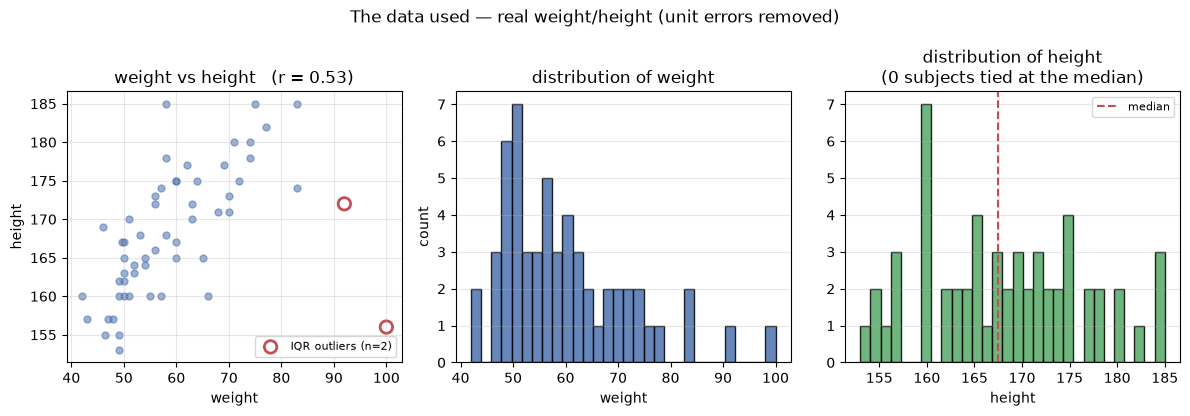

In [4]:
# The distribution of the data actually used: scatter + marginal histograms, IQR outliers flagged.
def iqr_outliers(v):
    q1, q3 = np.percentile(v, [25, 75]); iqr = q3 - q1
    return (v < q1 - 1.5*iqr) | (v > q3 + 1.5*iqr)
out = iqr_outliers(data[:, 0]) | iqr_outliers(data[:, 1])

fig = plt.figure(figsize=(12, 4.2))
ax0 = fig.add_subplot(1, 3, 1)
ax0.scatter(data[~out, 0], data[~out, 1], s=25, alpha=.55, color="#4c72b0")
if out.any():
    ax0.scatter(data[out, 0], data[out, 1], s=80, facecolors="none", edgecolors="#c44e52", lw=2,
                label=f"IQR outliers (n={int(out.sum())})")
    ax0.legend(fontsize=8)
ax0.set_xlabel(VARS[0]); ax0.set_ylabel(VARS[1]); ax0.grid(alpha=.3)
ax0.set_title(f"{VARS[0]} vs {VARS[1]}   (r = {np.corrcoef(data.T)[0,1]:.2f})")

ax1 = fig.add_subplot(1, 3, 2)
ax1.hist(data[:, 0], bins=30, color="#4c72b0", edgecolor="k", alpha=.85)
ax1.set_xlabel(VARS[0]); ax1.set_ylabel("count"); ax1.set_title(f"distribution of {VARS[0]}"); ax1.grid(alpha=.3, axis="y")

ax2 = fig.add_subplot(1, 3, 3)
ax2.hist(data[:, 1], bins=30, color="#55a868", edgecolor="k", alpha=.85)
ax2.axvline(np.median(data[:, 1]), color="#c44e52", ls="--", lw=1.5, label="median")
n_tied = int(np.sum(np.isclose(data[:, 1], np.median(data[:, 1]))))
ax2.set_xlabel(VARS[1]); ax2.set_title(f"distribution of {VARS[1]}\n({n_tied} subjects tied at the median)")
ax2.legend(fontsize=8); ax2.grid(alpha=.3, axis="y")

plt.suptitle(f"The data used — {source_note}")
plt.tight_layout(); plt.show()

## Experiment A — Structural: how far apart are the two sources, per statistic?

For each statistic on the ladder, `cov_diagnostics.covariance_report` builds the covariance both ways and
reports the **noise correlation** from each source (the only quantity that differs), plus the
**mean-identity error** `|Cov(LOO) − Cov(data)/(N−1)²|`.

The prediction is precise:

- **Mean** — for the linear mean, `Cov(LOO) = Cov(data)/(N−1)²` *exactly*, so the two correlations are equal
  and the identity error is ~machine-epsilon. This is the **anchor**: any nonzero divergence here would be a bug.
- **Non-linear** — a subject's influence on a median, trimmed mean, or variance is not its influence on the
  population spread, so `Cov(LOO)` departs from `Cov(data)`. Within the trimmed-mean family the divergence
  should **grow smoothly with the trim fraction** (the **median is trim-50%** — the limit of trimming
  everything but the middle — so it is the far endpoint of the *same* family); the **variance**, a different
  non-linear statistic, is included as an extra test point.

**Two quantities, don't confuse them.** The plots below show `|corr(LOO) − corr(DATA)|` — the difference in
noise **correlation**, which is the *only* thing the two mechanisms differ in (the supervisor rule matches the
marginals, and correlation is scale-invariant, so the `(N−1)²` factor cancels). The separate
`|Cov(LOO) − Cov(data)/(N−1)²|` is the **mean-identity error** — a correctness oracle that checks the two
covariance *objects* coincide up to that scaling — and it appears as the `mean_identity_err` column in the
table (~1e-16 only for the mean).

In [5]:
reps = {name: cd.covariance_report(data, fn, name=name) for name, fn in LADDER}
tabA = pd.DataFrame([{
    "statistic": n,
    "corr_from_data": reps[n]["data_corr"],
    "corr_from_LOO":  reps[n]["loo_corr"],
    "|divergence|":   abs(reps[n]["loo_corr"] - reps[n]["data_corr"]) if reps[n]["loo_corr"] is not None else np.nan,
    "mean_identity_err": reps[n]["mean_identity_err"],
} for n in reps])
print(tabA.to_string(index=False, float_format=lambda x: f"{x:.4g}"))

# the anchor, stated as a check
assert reps["mean"]["mean_identity_err"] < 1e-10, "mean identity must hold"
print("\nAnchor OK: for the mean, Cov(LOO) == Cov(data)/(N-1)^2 to machine precision.")

statistic  corr_from_data  corr_from_LOO  |divergence|  mean_identity_err
     mean          0.5332         0.5332     6.772e-15          1.769e-16
 trim-10%          0.5332         0.6759        0.1427           0.005662
 trim-20%          0.5332         0.6678        0.1346            0.01109
 trim-30%          0.5332         0.6917        0.1584            0.01384
   median          0.5332            NaN           NaN             0.2316
 variance          0.5332         0.2614        0.2718              24.54

Anchor OK: for the mean, Cov(LOO) == Cov(data)/(N-1)^2 to machine precision.


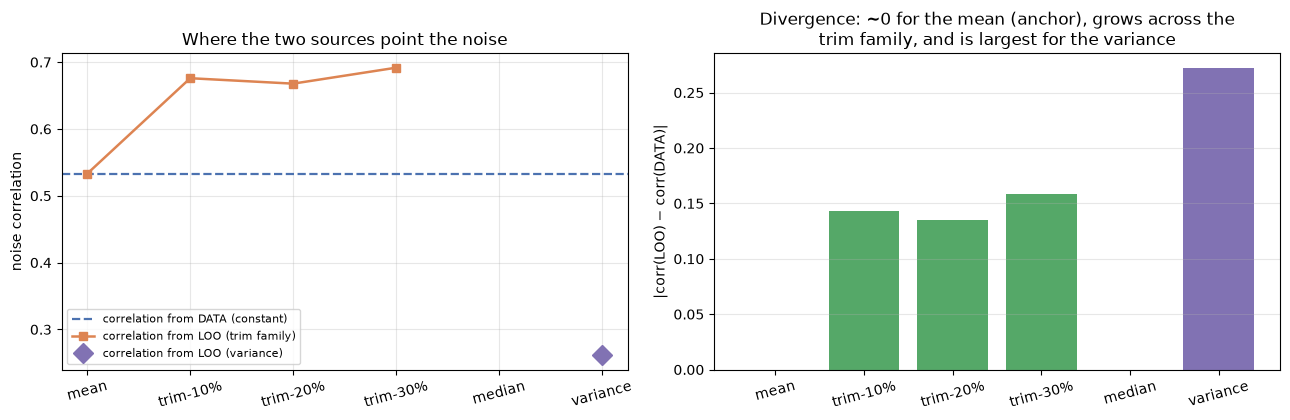

In [6]:
# Figure A1 — the two sources' noise correlation, and their divergence, per statistic
names = list(reps)
dcorr = [reps[n]["data_corr"] for n in names]
lcorr = [reps[n]["loo_corr"] if reps[n]["loo_corr"] is not None else np.nan for n in names]
div   = [abs(a-b) if not np.isnan(b) else np.nan for a, b in zip(dcorr, lcorr)]
x = np.arange(len(names))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
# DATA correlation is a property of the data, constant across statistics -> one flat reference line
ax[0].axhline(dcorr[0], color="#4c72b0", ls="--", lw=1.6, label="correlation from DATA (constant)")
# LOO correlation: connect the trim family (an ordered knob); show variance as a standalone marker
ax[0].plot(x[:N_TRIM], lcorr[:N_TRIM], "s-", color="#dd8452", lw=1.8, label="correlation from LOO (trim family)")
ax[0].plot(x[N_TRIM:], lcorr[N_TRIM:], "D", color="#8172b3", ms=10, label="correlation from LOO (variance)")
ax[0].set_xticks(x); ax[0].set_xticklabels(names, rotation=15); ax[0].set_ylabel("noise correlation")
ax[0].set_title("Where the two sources point the noise"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].bar(x, div, color=["#55a868"]*N_TRIM + ["#8172b3"]*(len(names)-N_TRIM))
ax[1].set_xticks(x); ax[1].set_xticklabels(names, rotation=15)
ax[1].set_ylabel("|corr(LOO) − corr(DATA)|")
ax[1].set_title("Divergence: ~0 for the mean (anchor), grows across the\ntrim family, and is largest for the variance")
ax[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

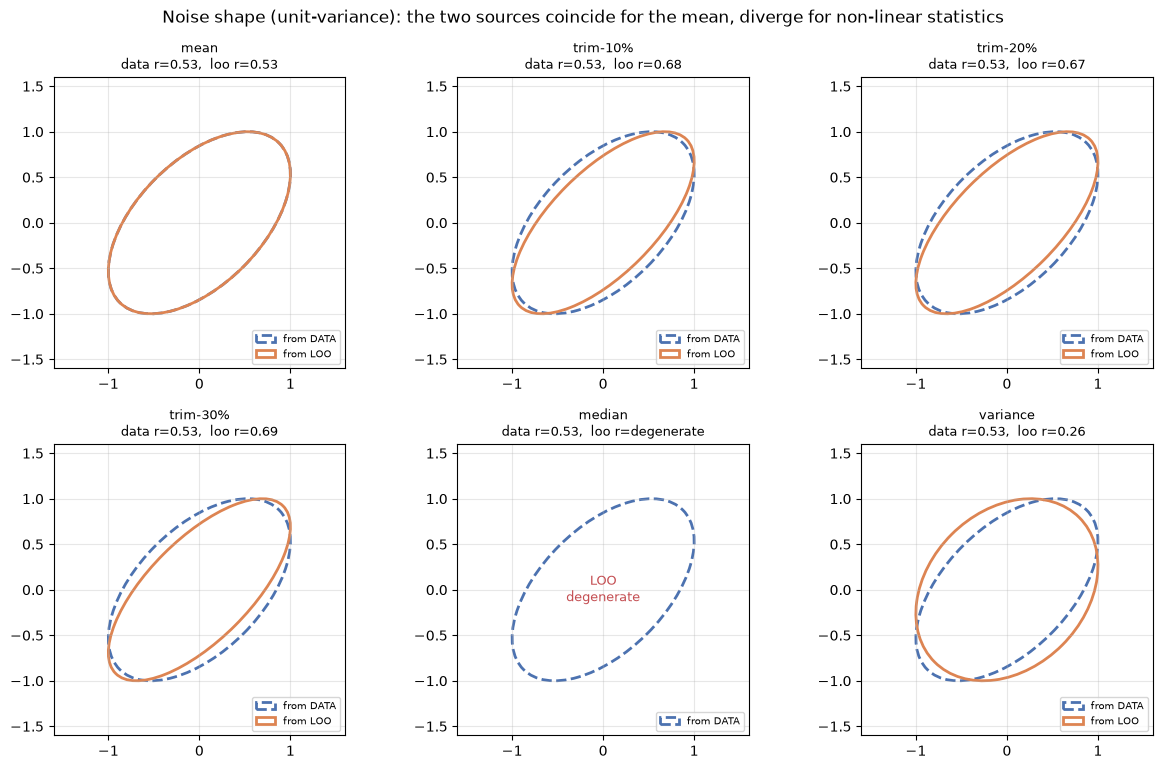

In [7]:
# Figure A2 — the same fact as a shape: unit-variance noise ellipse from each source.
# Same magnitude by construction, so any visible difference is the correlation alone.
def add_ellipse(ax, r, color, ls, label):
    C = np.array([[1, r], [r, 1]]); w, v = np.linalg.eigh(C)
    ang = np.degrees(np.arctan2(v[1, -1], v[0, -1]))
    ax.add_patch(Ellipse((0, 0), 2*np.sqrt(w[-1]), 2*np.sqrt(w[0]), angle=ang,
                         fill=False, color=color, ls=ls, lw=2, label=label))

# one panel per statistic; a degenerate LOO (correlation undefined) is labelled, not crashed
fmt = lambda v: "degenerate" if v is None else f"{v:.2f}"
names = list(reps); ncol = 3; nrow = int(np.ceil(len(names)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.1*ncol, 3.9*nrow))
for a, nm in zip(axes.ravel(), names):
    add_ellipse(a, reps[nm]["data_corr"], "#4c72b0", "--", "from DATA")
    if reps[nm]["loo_corr"] is not None:
        add_ellipse(a, reps[nm]["loo_corr"], "#dd8452", "-", "from LOO")
    else:
        a.text(0, 0, "LOO\ndegenerate", ha="center", va="center", color="#c44e52", fontsize=9)
    a.set_xlim(-1.6, 1.6); a.set_ylim(-1.6, 1.6); a.set_aspect("equal"); a.grid(alpha=.3)
    a.set_title(f"{nm}\ndata r={fmt(reps[nm]['data_corr'])},  loo r={fmt(reps[nm]['loo_corr'])}", fontsize=9)
    a.legend(fontsize=7, loc="lower right")
for a in axes.ravel()[len(names):]: a.axis("off")
plt.suptitle("Noise shape (unit-variance): the two sources coincide for the mean, diverge for non-linear statistics")
plt.tight_layout(); plt.show()

**Takeaway (A).** The data correlation is flat across every statistic — it is a property of the data, not the
statistic. The LOO correlation sits exactly on top of it for the **mean** (the anchor, identity error ~1e-16),
pulls away smoothly across the **trimmed-mean family**, and departs furthest for the **variance**. The ellipse
panels show the same fact as *shape*: the two ellipses are identical for the mean and visibly different for the
non-linear statistics. So "which covariance source" is a genuine modeling choice *only* for non-linear
statistics; for the mean the question is moot.

## Caveat — the median's degeneracy on coarse data (a blind spot)

Divergence is one thing; **degeneracy** is a sharper, separate failure. On coarsely-recorded data the median
can have **zero** LOO spread in a coordinate: many middle records are tied (rounded to the same value), so
removing any single subject leaves the median unchanged, `d_i = 0` for all *i*. The mechanism would then add
**no noise** to that coordinate — a silent privacy hole.

**What is "jitter"?** Jitter is a tiny amount of independent random noise added to each recorded value before
we recompute the statistic, scaled as a fraction of that column's standard deviation (x-axis below). It exists
only to **break the exact ties** created by rounding. The logic of the probe: if the zero LOO spread were a
*genuine* statement that no subject influences the median, jitter would not change it; but if the zero is
merely an **artifact of discrete recording**, then smoothing the ties with a vanishingly small jitter should
make the LOO noise reappear. It does — so the zero is an artifact, and the right response is to *detect and
flag* the degeneracy, not to trust the zero.

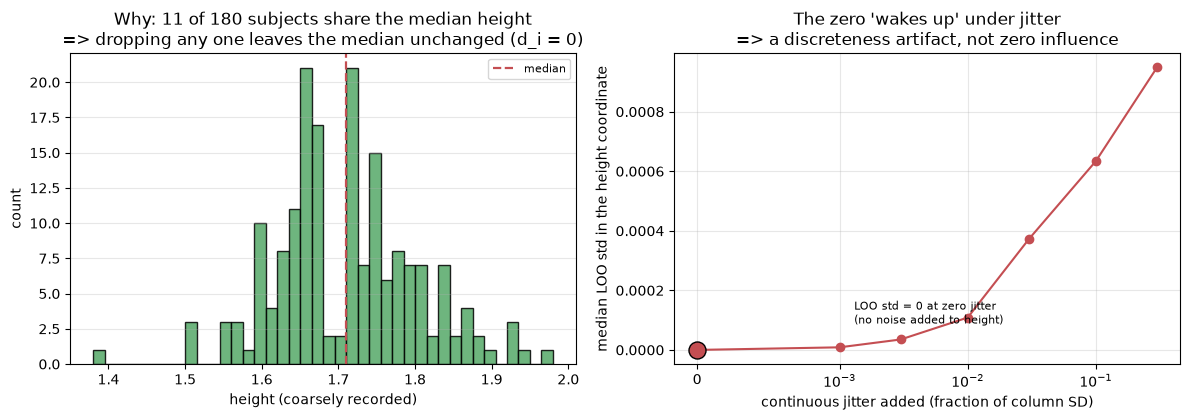

11/180 tied at median height;  height LOO std vs jitter: [0.0e+00 1.0e-05 4.0e-05 1.1e-04 3.7e-04 6.3e-04 9.5e-04]


In [8]:
# Coarse recording (height -> 1 cm) makes the median's LOO noise vanish in the height coordinate.
coarse = controlled_population(precision=[0.1, 0.01])   # weight 0.1 kg, height 1 cm
median = lambda d: np.median(d, 0)
def height_loo_std(X):
    full = median(X)
    D = np.array([median(np.delete(X, i, 0)) - full for i in range(len(X))])
    return D.std(0)[1]

col_sd = coarse.std(0); rng = np.random.default_rng(0); reps_j = 25
scales = [0, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]
H = [np.mean([height_loo_std(coarse + rng.normal(0, 1, coarse.shape)*col_sd*s) for _ in range(reps_j)])
     for s in scales]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))

# LEFT — WHY it degenerates: many subjects are tied at the median height value
med_h = np.median(coarse[:, 1]); n_tied = int(np.sum(coarse[:, 1] == med_h))
ax[0].hist(coarse[:, 1], bins=40, color="#55a868", edgecolor="k", alpha=.85)
ax[0].axvline(med_h, color="#c44e52", ls="--", lw=1.6, label="median")
ax[0].set_xlabel("height (coarsely recorded)"); ax[0].set_ylabel("count")
ax[0].set_title(f"Why: {n_tied} of {len(coarse)} subjects share the median height\n"
                "=> dropping any one leaves the median unchanged (d_i = 0)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3, axis="y")

# RIGHT — that the zero is an artifact: it wakes up under jitter
ax[1].plot(scales, H, "o-", color="#c44e52")
ax[1].scatter([0], [H[0]], s=150, color="#c44e52", edgecolor="k", zorder=5)   # the exact-zero point
ax[1].text(1.3e-3, max(H)*0.08, "LOO std = 0 at zero jitter\n(no noise added to height)", fontsize=8, va="bottom")
ax[1].set_xscale("symlog", linthresh=1e-3)
ax[1].set_xlabel("continuous jitter added (fraction of column SD)")
ax[1].set_ylabel("median LOO std in the height coordinate")
ax[1].set_title("The zero 'wakes up' under jitter\n=> a discreteness artifact, not zero influence")
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"{n_tied}/{len(coarse)} tied at median height;  height LOO std vs jitter:", np.round(H, 5))

**Takeaway (caveat).** The median's zero LOO noise on coarse data is a recording artifact, not a real
statement that the subject has no influence. It matters because it is a coordinate the mechanism would leave
**unprotected**, and — unlike the divergence above — choosing the data source does *not* rescue it: the noise
*magnitude* is always taken from the (degenerate) LOO, so both mechanisms add ~zero noise there. This is a
reason to detect degeneracy explicitly rather than a reason to prefer one covariance source.

## Experiment B — Outcome: does the divergence change measured privacy?

Structural divergence only matters if it changes what an attacker can do. The harness runs a
**membership-inference game**: a known background of N−1 subjects, a coin adds a target or not, and a held-out
**linear attacker** guesses IN vs OUT from the released (noised) statistic. The score is

> **membership advantage = TPR − FPR**  (0 = no detectable leakage, 1 = fully exposed),

averaged over several **seeds** and reported with a 95% CI. Here **TPR** = the rate the attacker guesses "IN"
when the target really *is* in, and **FPR** = the rate it guesses "IN" when the target is *out*. The gap
`TPR − FPR` is how much better than chance the attacker separates the two worlds: if the release carried no
information about the target, the attacker would say "IN" equally often either way (TPR = FPR) and the
advantage would be 0. (It is this direction, not `FPR − TPR`; a competent attacker has TPR ≥ FPR, so a
positive advantage means real leakage.) The meaningful scale is **0 = safe → 1 = fully exposed**. The metric
*can* dip slightly below 0, but that is not "extra safe": it just means the held-out attacker did marginally
worse than chance by sampling noise (and an anti-correlated attacker carries the same information as a correct
one — flip its guess). So read small negative values as ≈ 0, and treat **−1 as equivalent to full exposure**,
not safety. It is a *lower bound* on leakage — an attack proves leakage, a failed attack does not prove
safety — so we compare the two sources to each other. We run **mean, trim-20%, median, and variance**.
Overlapping CIs mean the covariance source makes **no robust difference to privacy**.

In [9]:
source = ph.TabularSource(data, N=min(60, len(data)))
mechs  = {"data": ph.make_covsource_mechanism("data"),   # correlation from Cov(subject data)
          "loo":  ph.make_covsource_mechanism("loo")}    # correlation from Cov(LOO perturbations)
eval_pipes = {"mean": ph.pipeline_mean, "trim-20%": make_trim(0.20),
              "median": lambda s: np.median(s, 0), "variance": ph.pipeline_variance}
SEEDS = (1, 2, 3, 4, 5, 6)      # scale up for tighter CIs

parts = []
for pname, pipe in eval_pipes.items():
    d = ph.sweep(source, pipe, mechs, N_list=[source.N], power_scales=None,   # intrinsic (supervisor) scale
                 seeds=SEEDS, n_trials=1500, n_rel=50)
    d["statistic"] = pname; parts.append(d)
raw = pd.concat(parts, ignore_index=True)
agg = ph.aggregate_sweep(raw, group_cols=("statistic", "mechanism"),
                         metrics=("empirical_adv", "fallback_rate"))
print(agg[["statistic", "mechanism", "n_seeds", "empirical_adv_mean",
           "empirical_adv_lo", "empirical_adv_hi", "fallback_rate_mean"]]
      .round(3).to_string(index=False))

statistic mechanism  n_seeds  empirical_adv_mean  empirical_adv_lo  empirical_adv_hi  fallback_rate_mean
     mean      data        6               0.251             0.212             0.291               0.000
     mean       loo        6               0.251             0.212             0.291               0.000
   median      data        6               0.470             0.447             0.493               0.000
   median       loo        6               0.480             0.458             0.502               0.000
 trim-20%      data        6               0.317             0.289             0.344               0.000
 trim-20%       loo        6               0.237             0.185             0.290               0.000
 variance      data        6               0.462             0.401             0.524               0.000
 variance       loo        6               0.469             0.398             0.540               0.008


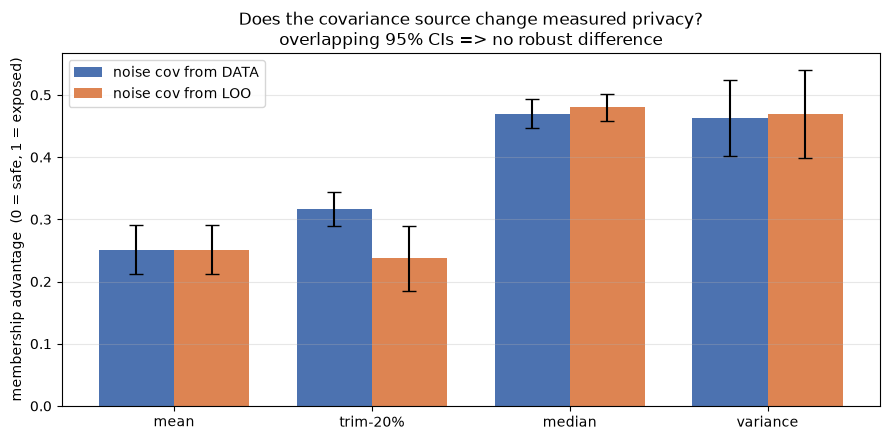

In [10]:
# Figure B — membership advantage, DATA vs LOO source, per statistic (95% CI over seeds)
stats = list(eval_pipes); x = np.arange(len(stats)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, srcn in enumerate(["data", "loo"]):
    s = agg[agg.mechanism == srcn].set_index("statistic").reindex(stats)
    yerr = [s.empirical_adv_mean - s.empirical_adv_lo, s.empirical_adv_hi - s.empirical_adv_mean]
    ax.bar(x + (i-0.5)*w, s.empirical_adv_mean, w, yerr=yerr, capsize=5,
           color=["#4c72b0", "#dd8452"][i], label=f"noise cov from {srcn.upper()}")
ax.set_xticks(x); ax.set_xticklabels(stats)
ax.set_ylabel("membership advantage  (0 = safe, 1 = exposed)")
ax.set_title("Does the covariance source change measured privacy?\noverlapping 95% CIs => no robust difference")
ax.legend(); ax.grid(alpha=.3, axis="y")
# the mean bars must be identical (anchor); trim/median overlap => source is neutral for privacy here
plt.tight_layout(); plt.show()

**Takeaway (B).** The **mean** bars are identical (they must be — the anchor). For **trim-20%**, the
**median**, and the **variance**, the DATA and LOO bars overlap within their 95% CIs: the structural
divergence from Experiment A does **not** translate into a measurable privacy difference at `p = 2`. The
covariance source is *scientifically neutral* for membership privacy on this bivariate data. The one place the
source leaves a fingerprint is the **fallback rate** (printed above): for the variance, the LOO covariance
rejection-samples less easily and falls back to independent noise more often — a mechanism-health signal, not
a privacy gain.

## Conclusions

- **Structural (A).** The two covariance sources coincide exactly for the linear **mean** (`Cov(LOO) =
  Cov(data)/(N−1)²`, error ~1e-16), diverge smoothly across the **trimmed-mean family**, and diverge most for
  the **variance**. "Which source" is only a real choice for non-linear statistics.
- **Outcome (B).** That divergence does **not** move membership advantage at `p = 2` — the DATA and LOO
  mechanisms are indistinguishable within seed CIs for every statistic tested (mean, trim-20%, median,
  variance). Structurally different, operationally equivalent here; the only trace is a higher LOO fallback
  rate for the variance.
- **Caveat.** On coarse data the median develops a **zero-noise blind spot** in a coordinate; this is a
  degeneracy to *detect*, and the covariance source does not fix it (the magnitude comes from the LOO either way).

**Where the source is expected to matter** is exactly where `p = 2` cannot show it: **high-dimensional,
strongly-correlated outputs** (imaging / mass-univariate maps), where the LOO correlation structure carries
far more information than a single off-diagonal term. That is the regime `baseline_A` targets — the same two
mechanisms (`make_covsource_mechanism('data' | 'loo')`) drop straight onto an `ArrayBlockSource` of image
patches, and the harness's spatial utility metric (`neighbour_corr_gap`) becomes the axis this bivariate case
was blind to. Nothing here is a DP guarantee; membership advantage is a lower bound on leakage.